# Proposal-system evolution

**Monthly** time series of the
proposal pipeline across projects (KEP — Kubernetes, KEEP — Kotlin, and the others in
`all_proposals.db`).

Based on when a proposal was **first seen** (`first_seen_at`,
earliest revision or status) and when it **first reached a terminal status**
(`first_terminal_at` — `accepted` / `rejected` / `withdrawn` / `superseded`).

1. Monthly proposal inflow — newly introduced proposals per month, per project.
2. Cumulative unresolved (open) proposals — running backlog of not-yet-terminal proposals.

Each is shown as a line chart, a stacked bar chart, and a per-project **z-score
normalized** line so projects of very different sizes can be compared by shape.

In [23]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)

%config InlineBackend.figure_format = 'retina'

In [24]:
candidate_paths = [
    Path("data/shared/all_proposals.db"),
    Path("../data/shared/all_proposals.db"),
    Path("../../data/shared/all_proposals.db"),
    Path("../../../data/shared/all_proposals.db"),
    Path("../../../../data/shared/all_proposals.db"),
]
db_path = next((p.resolve() for p in candidate_paths if p.exists()), None)
if db_path is None:
    raise FileNotFoundError("all_proposals.db not found from any candidate path")
print(f"Using {db_path}")
conn = sqlite3.connect(db_path)

Using C:\Users\kajus\IdeaProjects\cse3000-monorepo\rq3-kep-keep\data\shared\all_proposals.db


## 0 · Per-proposal base table

One row per proposal with just the fields the monthly views need: `project_name`,
its `first_seen_at`, its latest status, and the first terminal transition
(`first_terminal_at` + `terminal_status`, NULL if it never reached one).

In [25]:
base_sql = """
           WITH first_seen AS (SELECT project_id, proposal_id, MIN(created_at) AS first_seen_at
                               FROM (SELECT project_id, proposal_id, created_at
                                     FROM ProposalRevision
                                     UNION ALL
                                     SELECT project_id, proposal_id, created_at
                                     FROM ProposalStatus)
                               GROUP BY project_id, proposal_id),
                latest AS (SELECT project_id,
                                  proposal_id,
                                  normalised_status AS latest_status,
                                  MAX(created_at)   AS latest_status_at
                           FROM ProposalStatus
                           GROUP BY project_id, proposal_id),
                first_terminal AS (SELECT project_id,
                                          proposal_id,
                                          MIN(created_at)   AS first_terminal_at,
                                          normalised_status AS terminal_status
                                   FROM ProposalStatus
                                   WHERE normalised_status IN ('accepted', 'rejected', 'withdrawn', 'superseded')
                                   GROUP BY project_id, proposal_id)
           SELECT pr.project_name,
                  p.project_id,
                  p.proposal_id,
                  fs.first_seen_at,
                  l.latest_status,
                  ft.first_terminal_at,
                  ft.terminal_status
           FROM Proposal p
                  JOIN Project pr ON pr.project_id = p.project_id
                  JOIN first_seen fs ON fs.project_id = p.project_id AND fs.proposal_id = p.proposal_id
                  JOIN latest l ON l.project_id = p.project_id AND l.proposal_id = p.proposal_id
                  LEFT JOIN first_terminal ft ON ft.project_id = p.project_id AND ft.proposal_id = p.proposal_id \
           """

proposals = pd.read_sql_query(base_sql, conn)

# Date formats differ per project (tz'd 'T', naive 'T', numeric offsets, and
# space-separated microseconds). format='mixed' parses each row independently;
# without it pandas locks onto one format and silently returns NaT for the rest.
_parse = lambda col: pd.to_datetime(col, errors="coerce", utc=True, format="mixed")
proposals["first_seen_at"] = _parse(proposals["first_seen_at"])
proposals["first_terminal_at"] = _parse(proposals["first_terminal_at"])

proposals

,project_name,project_id,proposal_id,first_seen_at,latest_status,first_terminal_at,terminal_status
0,Python,0,1,2019-07-16 15:11:36+00:00,accepted,2019-07-16 15:11:36+00:00,accepted
1,Python,0,10,2002-03-07 19:20:45+00:00,accepted,2002-03-07 19:20:45+00:00,accepted
2,Python,0,100,2001-06-27 17:11:33+00:00,accepted,2001-06-27 17:11:33+00:00,accepted
3,Python,0,101,2018-10-27 09:22:27+00:00,accepted,2018-10-27 09:22:27+00:00,accepted
4,Python,0,102,2002-01-10 15:46:28+00:00,superseded,2002-01-10 15:46:28+00:00,accepted
...,...,...,...,...,...,...,...
7986,Kotlin,9,0458,2026-03-30 10:06:02+00:00,review,NaT,NaN
7987,Kotlin,9,0459,2026-04-09 16:01:05+00:00,draft,NaT,NaN
7988,Kotlin,9,0460,2026-05-12 08:29:00+00:00,review,NaT,NaN
7989,Kotlin,9,0461,2026-05-05 13:41:09+00:00,review,NaT,NaN


## 1 · Monthly proposal inflow

Newly introduced proposals broken down by *month* (anchored on `first_seen_at`),
keeping `project_name` as the hue so cross-project differences stay visible. Shown as
a line chart (trend) and a stacked bar chart (composition).

C:\Users\kajus\AppData\Local\Temp\ipykernel_8932\1760301412.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda df: df["first_seen_at"].dt.to_period("M").dt.to_timestamp())


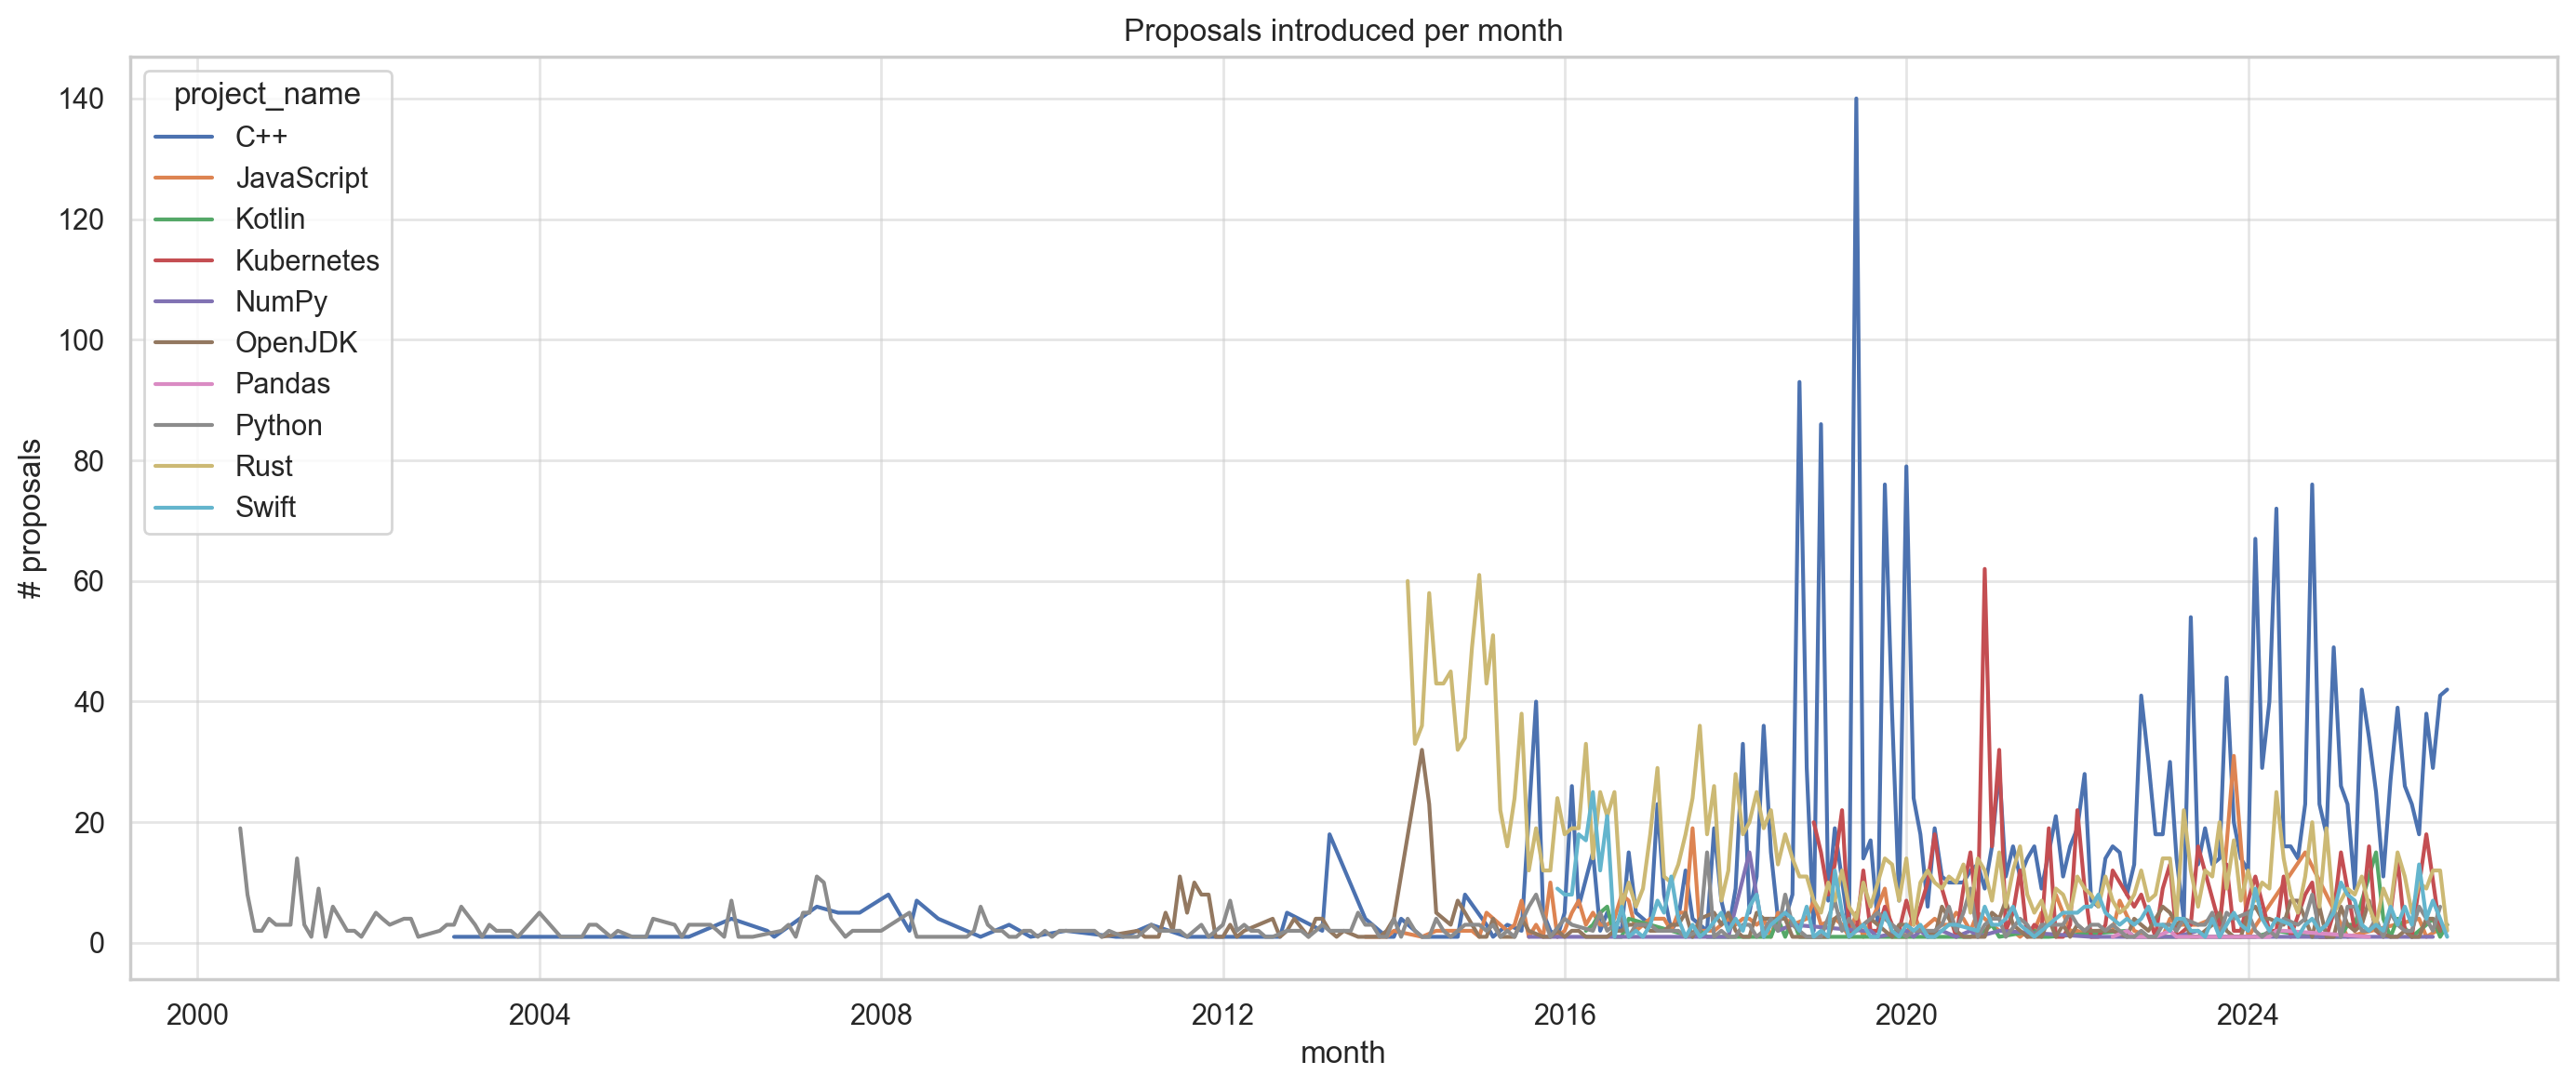

In [26]:
monthly_new = (
    proposals.dropna(subset=["first_seen_at"])
    .assign(month=lambda df: df["first_seen_at"].dt.to_period("M").dt.to_timestamp())
    .groupby(["project_name", "month"])
    .size()
    .reset_index(name="count")
    .sort_values(["project_name", "month"])
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=monthly_new, x="month", y="count", hue="project_name", ax=ax)
ax.set_title("Proposals introduced per month")
ax.set_xlabel("month")
ax.set_ylabel("# proposals")
plt.tight_layout()
plt.show()

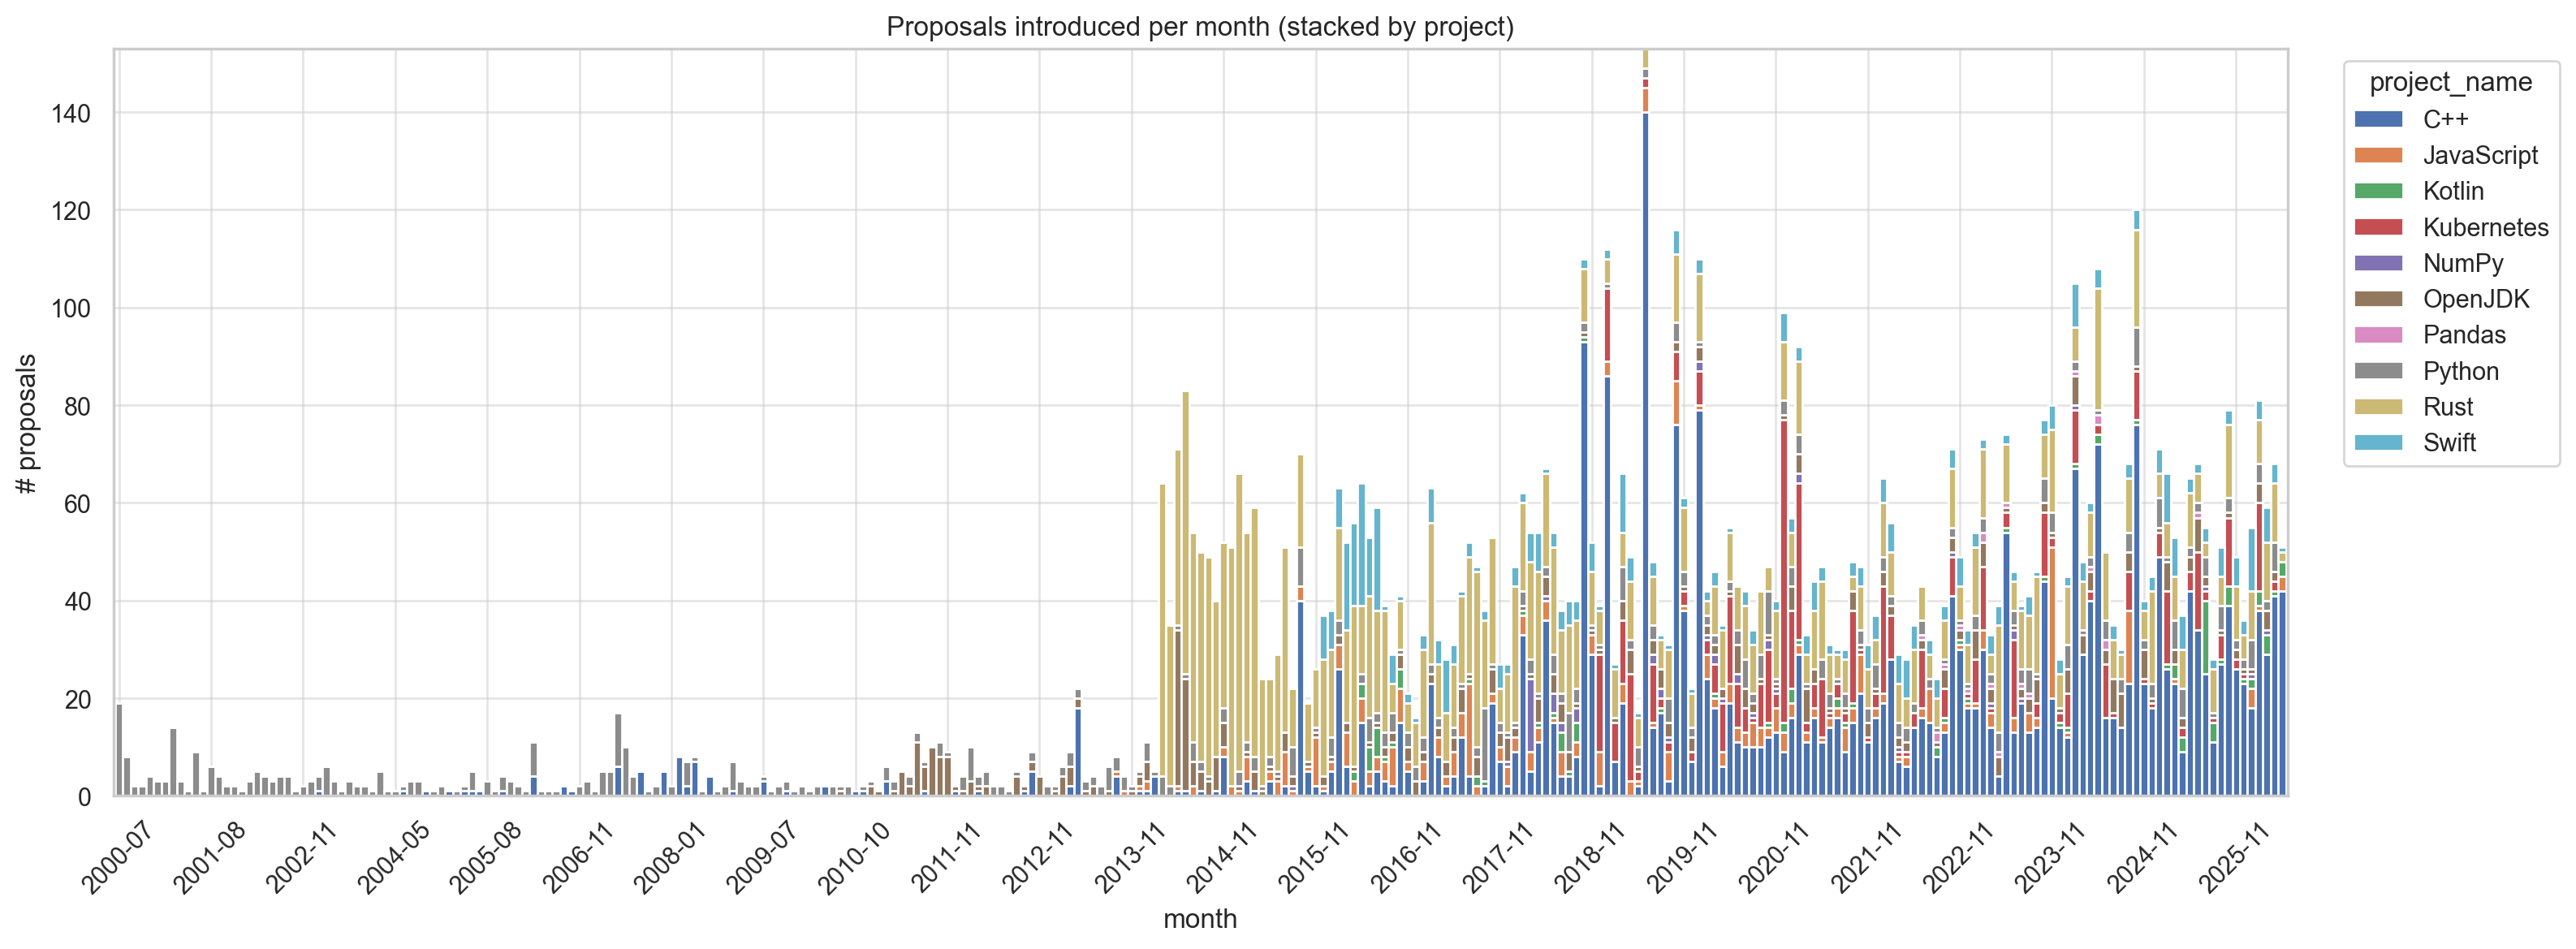

In [27]:
pivot_new = (
    monthly_new.pivot(index="month", columns="project_name", values="count")
    .fillna(0)
    .sort_index()
)
pivot_new.index = pivot_new.index.strftime("%Y-%m")  # categorical labels, avoids date converter

ax = pivot_new.plot(kind="bar", stacked=True, figsize=(16, 6), width=1.0)
ax.set_title("Proposals introduced per month (stacked by project)")
ax.set_xlabel("month")
ax.set_ylabel("# proposals")
step = 12
ticks = list(range(0, len(pivot_new.index), step))
ax.set_xticks(ticks)
ax.set_xticklabels([pivot_new.index[i] for i in ticks], rotation=45)
ax.legend(title="project_name", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

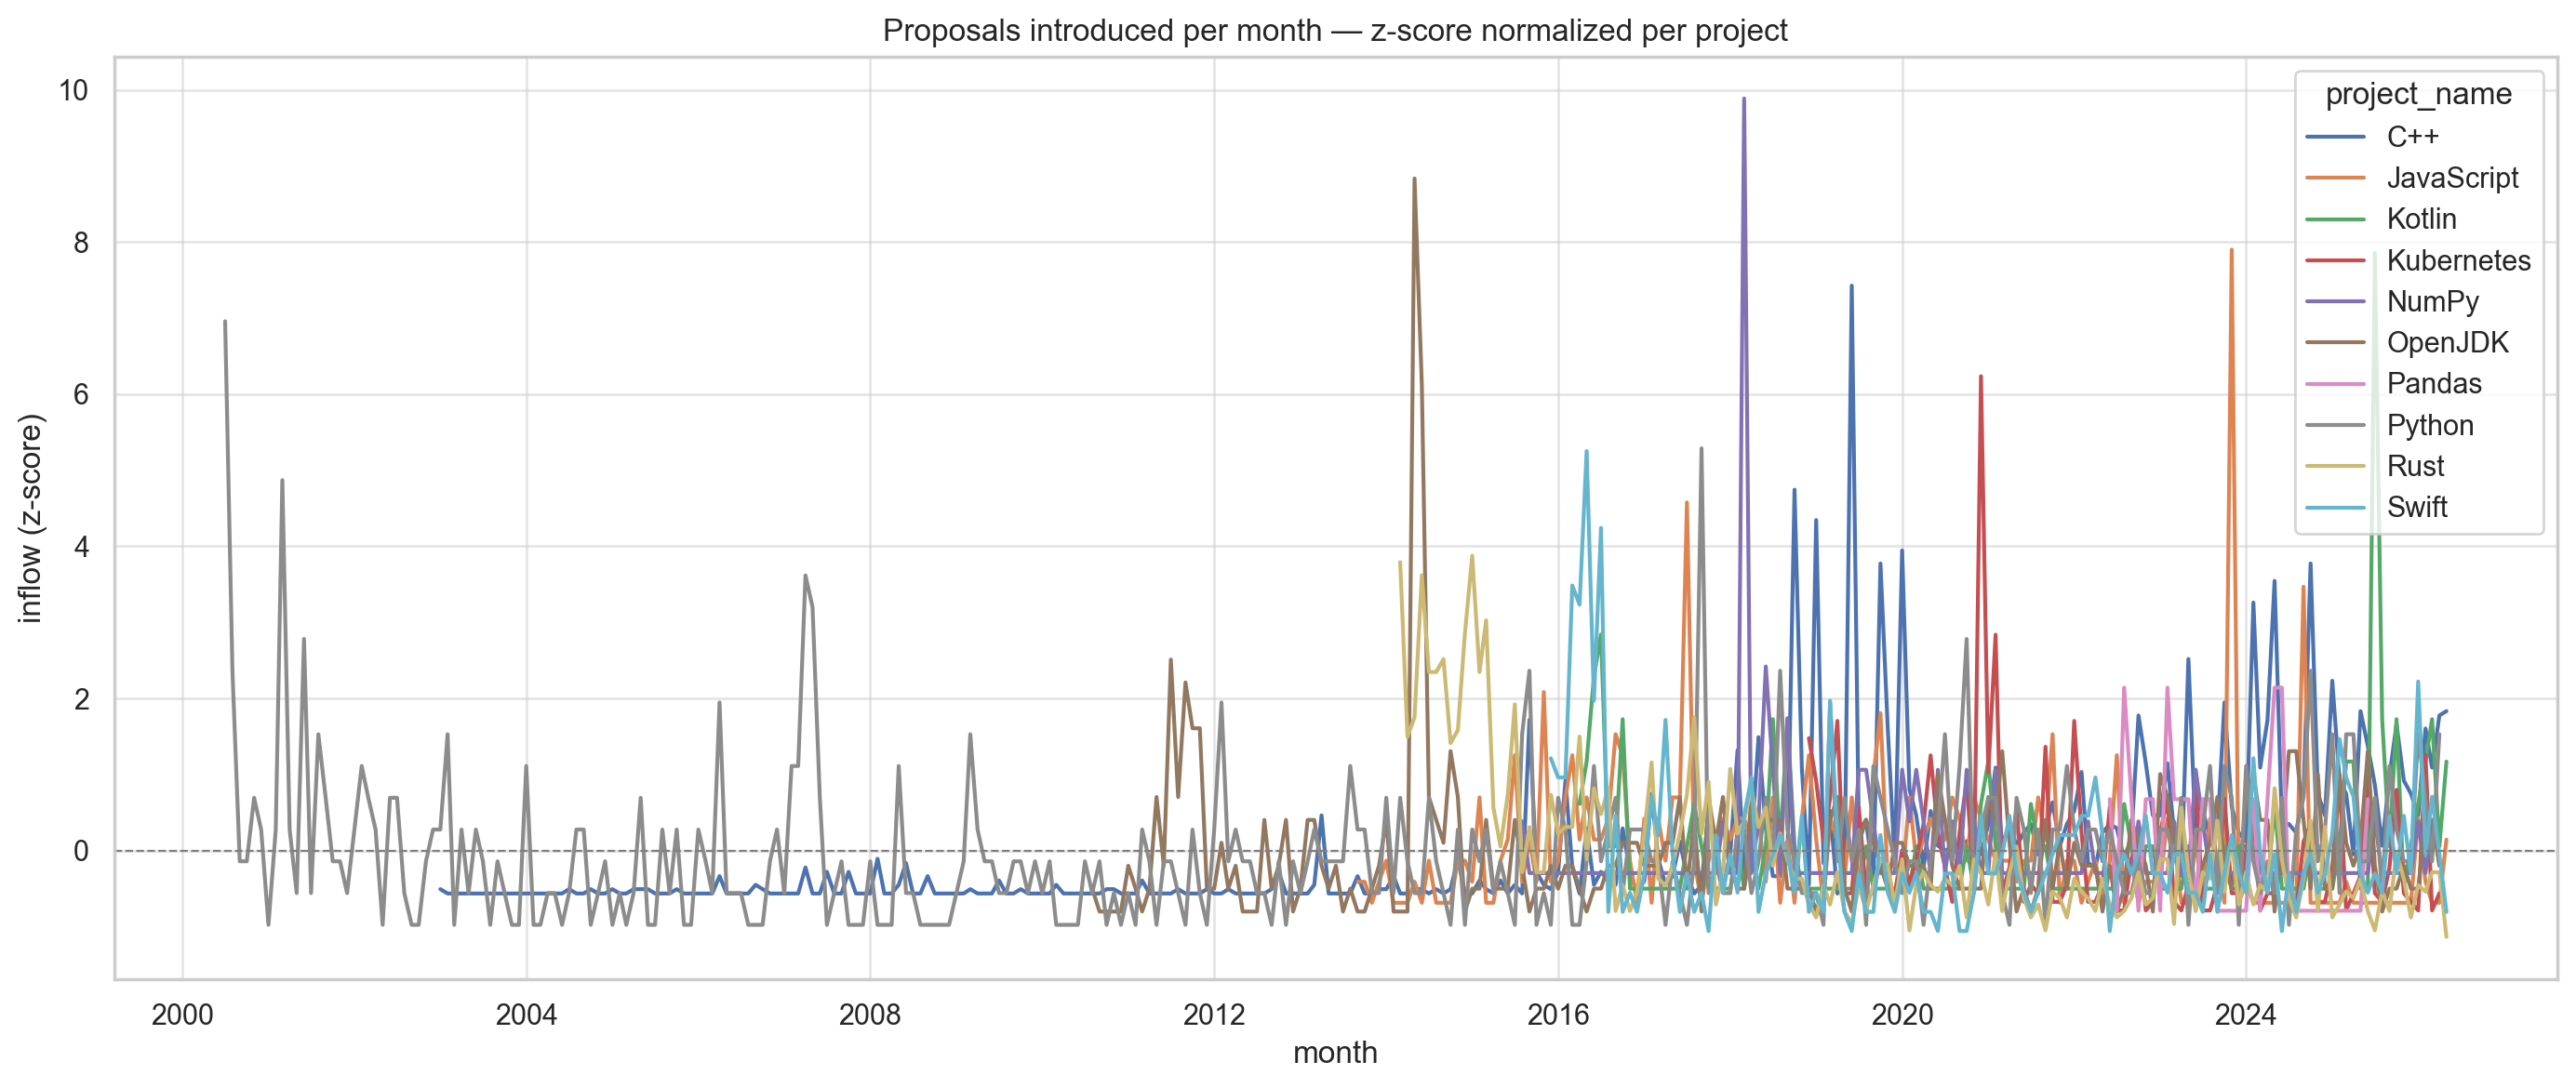

In [28]:
# z-score each project's monthly series over its own active span (interior gaps
# filled with 0) so projects of very different sizes become comparable by *shape*
# rather than absolute magnitude.
def _zscore_by_project(long_df, value_col):
    out = []
    for proj, g in long_df.groupby("project_name"):
        s = g.set_index("month")[value_col].sort_index()
        months = pd.period_range(
            s.index.min().to_period("M"), s.index.max().to_period("M"), freq="M"
        ).to_timestamp()
        s = s.reindex(months, fill_value=0)
        sd = s.std(ddof=0)
        z = (s - s.mean()) / sd if sd > 0 else s * 0.0
        out.append(pd.DataFrame({
            "project_name": proj,
            "month": months,
            value_col: s.to_numpy(),
            f"{value_col}_z": z.to_numpy(),
        }))
    return pd.concat(out, ignore_index=True)


monthly_new_z = _zscore_by_project(monthly_new, "count")

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=monthly_new_z, x="month", y="count_z", hue="project_name", ax=ax)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_title("Proposals introduced per month — z-score normalized per project")
ax.set_xlabel("month")
ax.set_ylabel("inflow (z-score)")
plt.tight_layout()
plt.show()

## 2 · Cumulative unresolved (open) proposals

A proposal is **unresolved** until it first reaches a terminal status (i.e. until
`first_terminal_at`). The running backlog — cumulative introduced minus cumulative
resolved, per month — shows how the pool of still-open proposals has grown for each
project. Shown as a line chart, a stacked bar chart, and a z-score normalized line.

C:\Users\kajus\AppData\Local\Temp\ipykernel_8932\3337740225.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  introduced = g["first_seen_at"].dropna().dt.to_period("M")
C:\Users\kajus\AppData\Local\Temp\ipykernel_8932\3337740225.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  resolved = g["first_terminal_at"].dropna().dt.to_period("M")
C:\Users\kajus\AppData\Local\Temp\ipykernel_8932\3337740225.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  introduced = g["first_seen_at"].dropna().dt.to_period("M")
C:\Users\kajus\AppData\Local\Temp\ipykernel_8932\3337740225.py:7: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  resolved = g["first_terminal_at"].dropna().dt.to_period("M")
C:\Users\kajus\AppData\Local\Temp\ipykernel_8932\3337740225.py:6: UserWarning: Converting to PeriodArray/Index represent

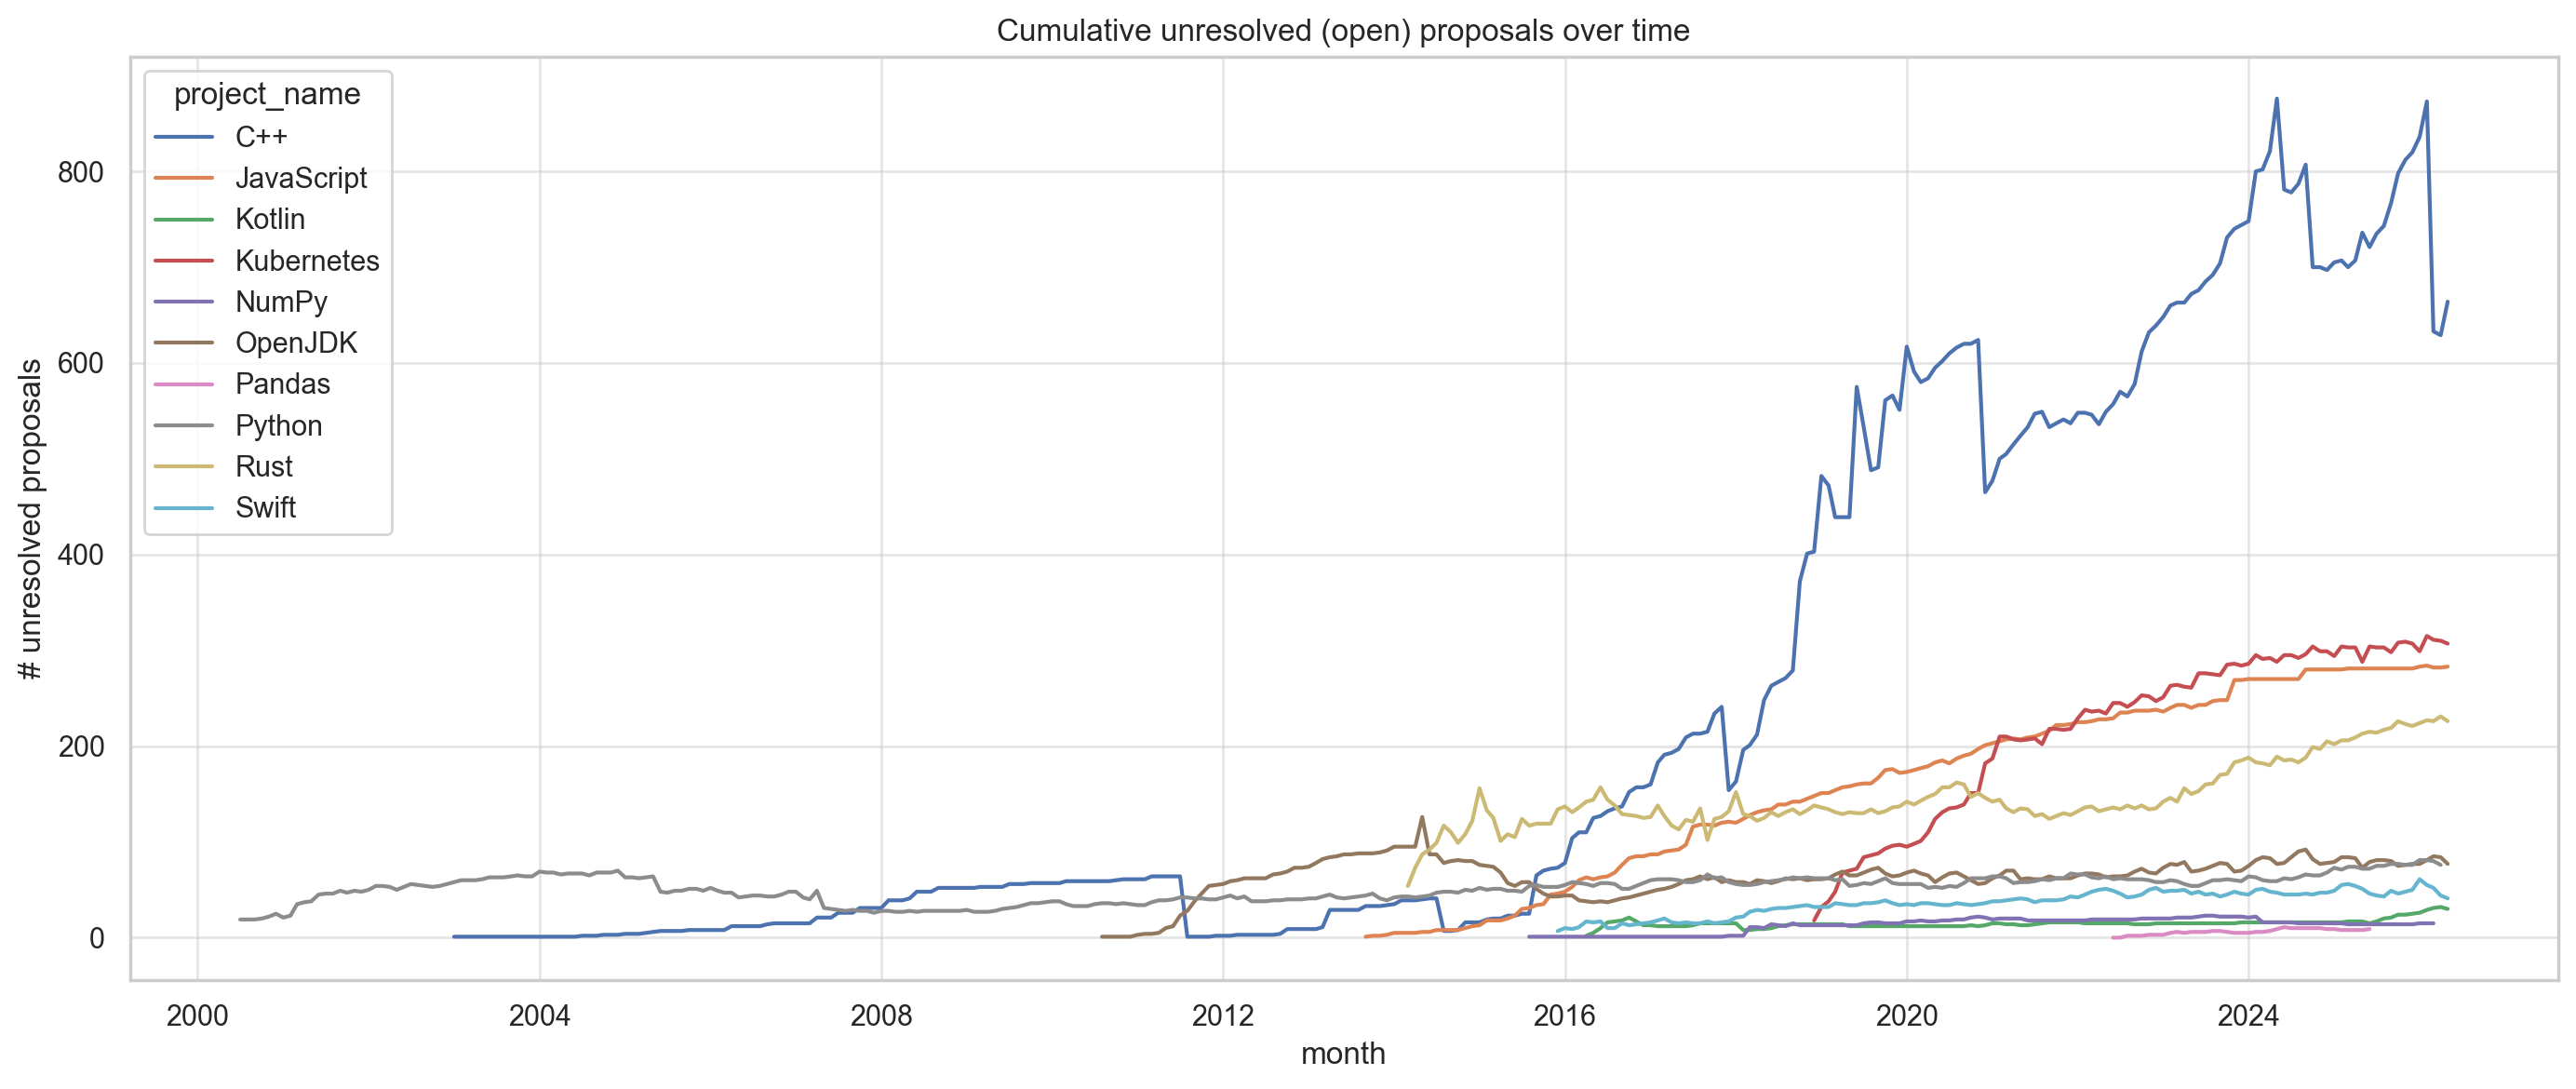

In [29]:
def _monthly_unresolved(df):
    """Per project, the running backlog of open proposals per month:
    cumulative(introduced) - cumulative(reached a terminal status)."""
    frames = []
    for proj, g in df.groupby("project_name"):
        introduced = g["first_seen_at"].dropna().dt.to_period("M")
        resolved = g["first_terminal_at"].dropna().dt.to_period("M")
        if introduced.empty:
            continue
        end = introduced.max()
        if not resolved.empty:
            end = max(end, resolved.max())
        months = pd.period_range(introduced.min(), end, freq="M")
        intro_c = introduced.value_counts().reindex(months, fill_value=0).sort_index()
        res_c = resolved.value_counts().reindex(months, fill_value=0).sort_index()
        net = (intro_c - res_c).cumsum()
        frames.append(pd.DataFrame({
            "project_name": proj,
            "month": months.to_timestamp(),
            "unresolved": net.to_numpy(),
        }))
    return pd.concat(frames, ignore_index=True)


unresolved = _monthly_unresolved(proposals).sort_values(["project_name", "month"])

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=unresolved, x="month", y="unresolved", hue="project_name", ax=ax)
ax.set_title("Cumulative unresolved (open) proposals over time")
ax.set_xlabel("month")
ax.set_ylabel("# unresolved proposals")
plt.tight_layout()
plt.show()

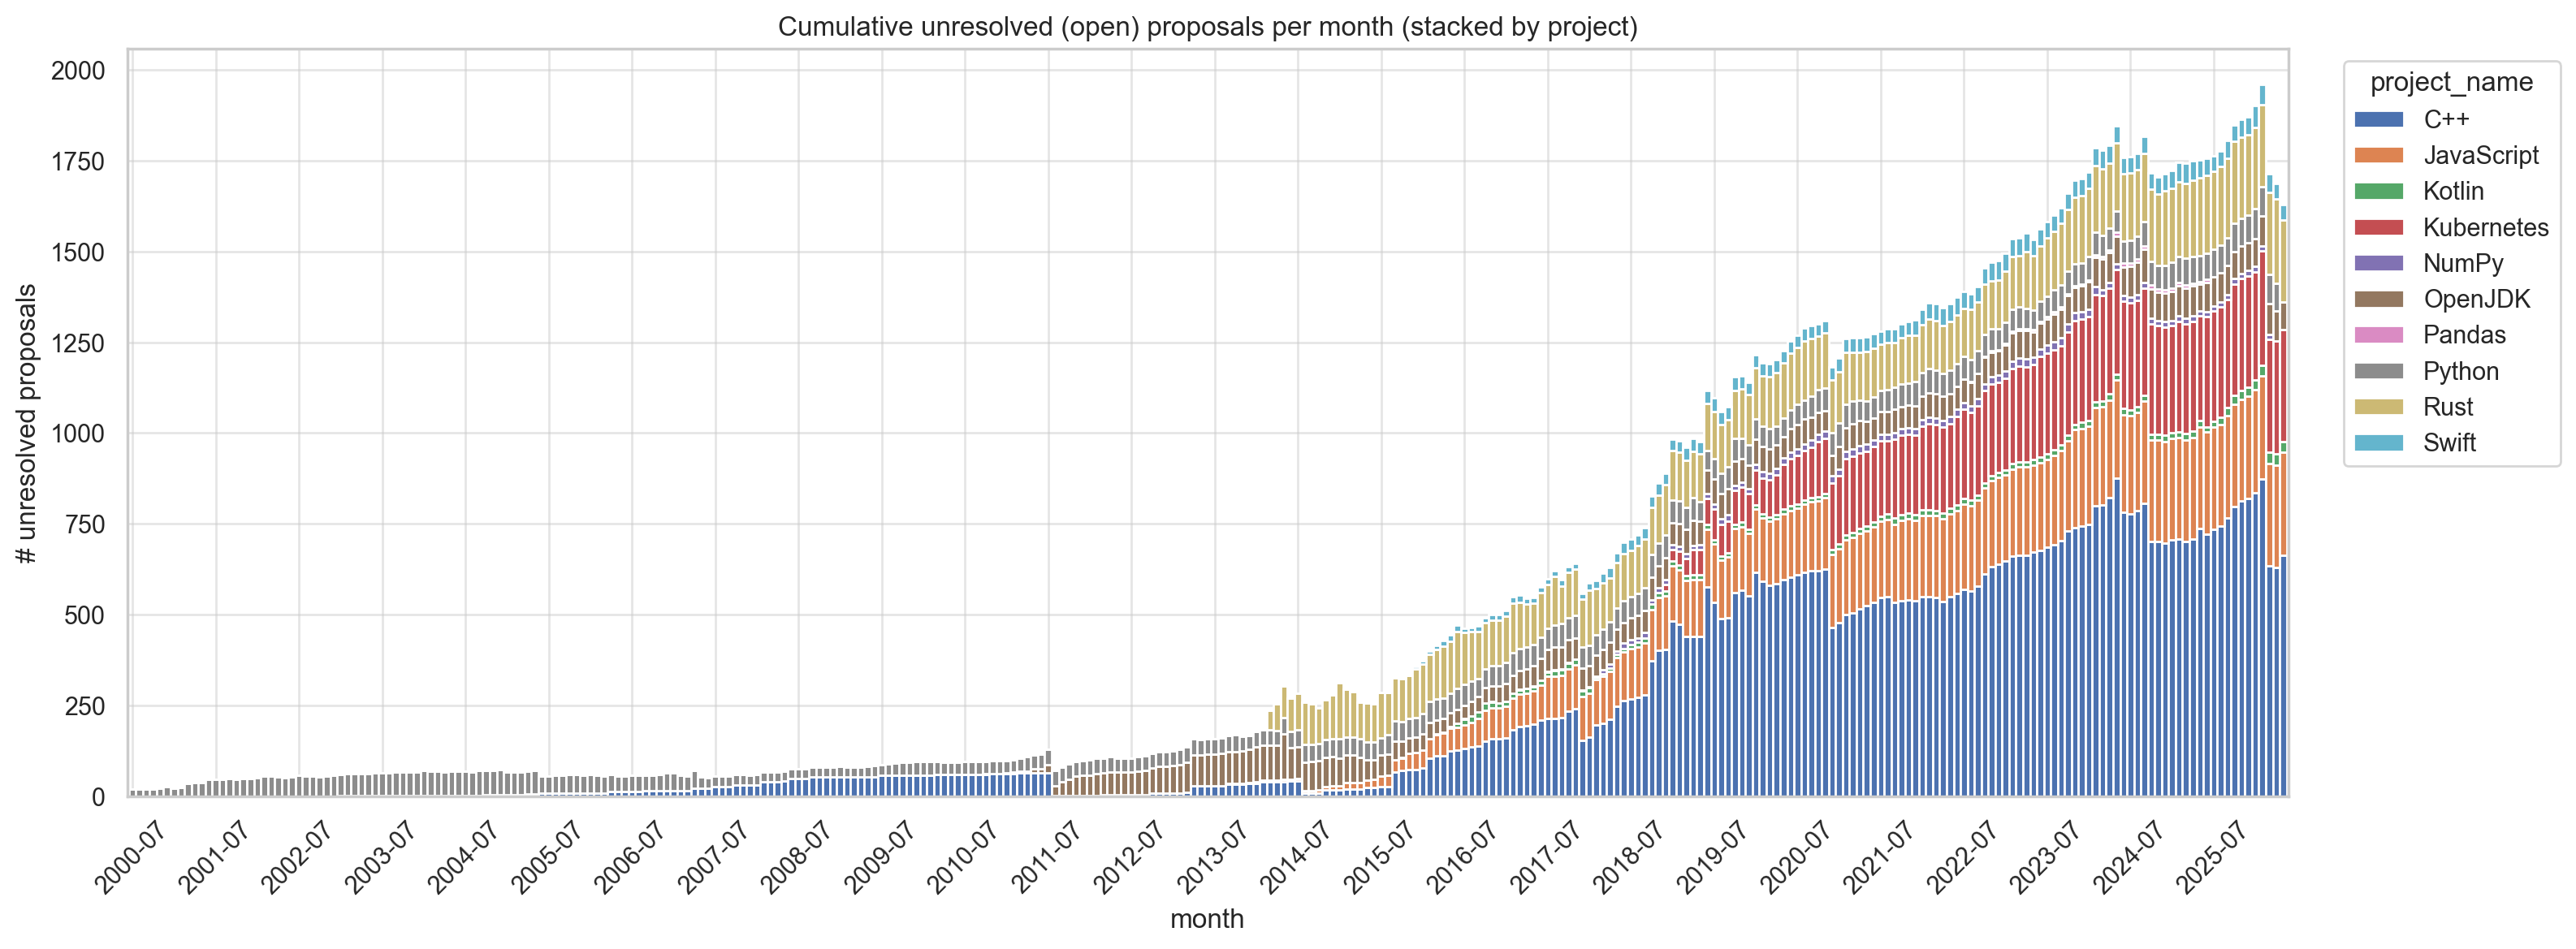

In [30]:
pivot_unresolved = (
    unresolved.pivot(index="month", columns="project_name", values="unresolved")
    .fillna(0)
    .sort_index()
)
pivot_unresolved.index = pivot_unresolved.index.strftime("%Y-%m")  # categorical labels, avoids date converter

ax = pivot_unresolved.plot(kind="bar", stacked=True, figsize=(16, 6), width=1.0)
ax.set_title("Cumulative unresolved (open) proposals per month (stacked by project)")
ax.set_xlabel("month")
ax.set_ylabel("# unresolved proposals")
step = 12
ticks = list(range(0, len(pivot_unresolved.index), step))
ax.set_xticks(ticks)
ax.set_xticklabels([pivot_unresolved.index[i] for i in ticks], rotation=45)
ax.legend(title="project_name", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

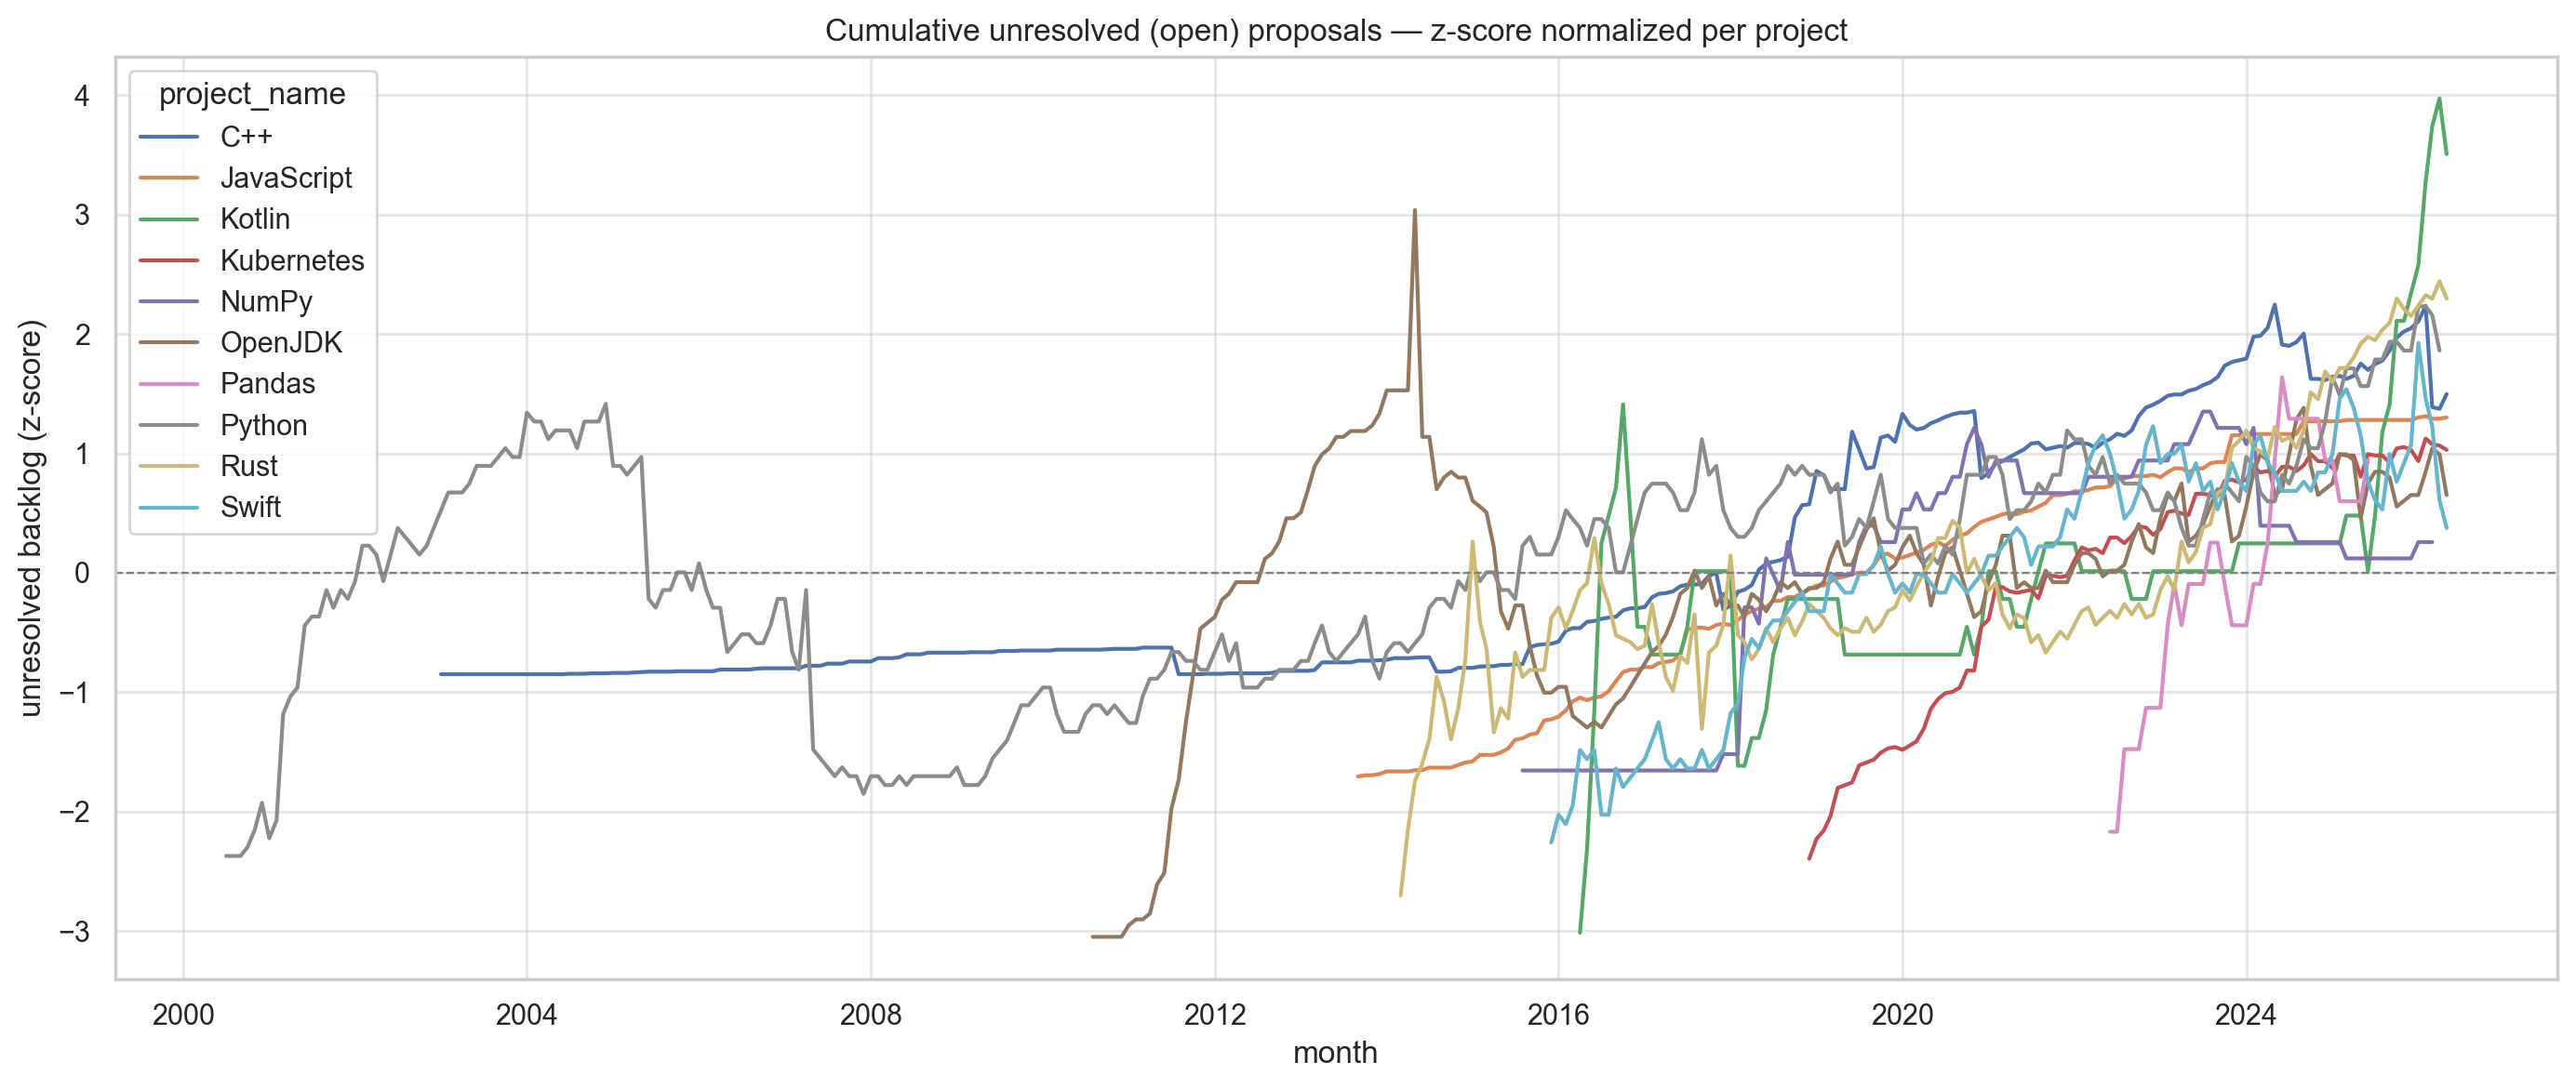

In [31]:
# Same per-project z-score normalization for the cumulative unresolved backlog,
# so the shape of each project's open-proposal curve is comparable regardless of
# absolute size. (unresolved is already a continuous monthly series per project.)
unresolved_z = _zscore_by_project(unresolved, "unresolved")

fig, ax = plt.subplots(figsize=(14, 6))
sns.lineplot(data=unresolved_z, x="month", y="unresolved_z", hue="project_name", ax=ax)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_title("Cumulative unresolved (open) proposals — z-score normalized per project")
ax.set_xlabel("month")
ax.set_ylabel("unresolved backlog (z-score)")
plt.tight_layout()
plt.show()

## 3 · First seven years per project (relative time)

The absolute-time charts above are dominated by projects' different start dates and sizes. Here we re-base every project to **months since its own first proposal** (x-axis starts at 0) and keep only the **first 7 years (84 months)**, so the early trajectories line up and can be compared directly — both as raw counts and z-score normalized per project.

Inflow gaps are filled with 0; the unresolved backlog (a running level) is forward-filled. Windows are clipped to the dataset's latest month, so a project younger than 7 years simply shows a shorter line (all projects except Pandas are at least 7 years old, the Pandas project is left out for this reason).

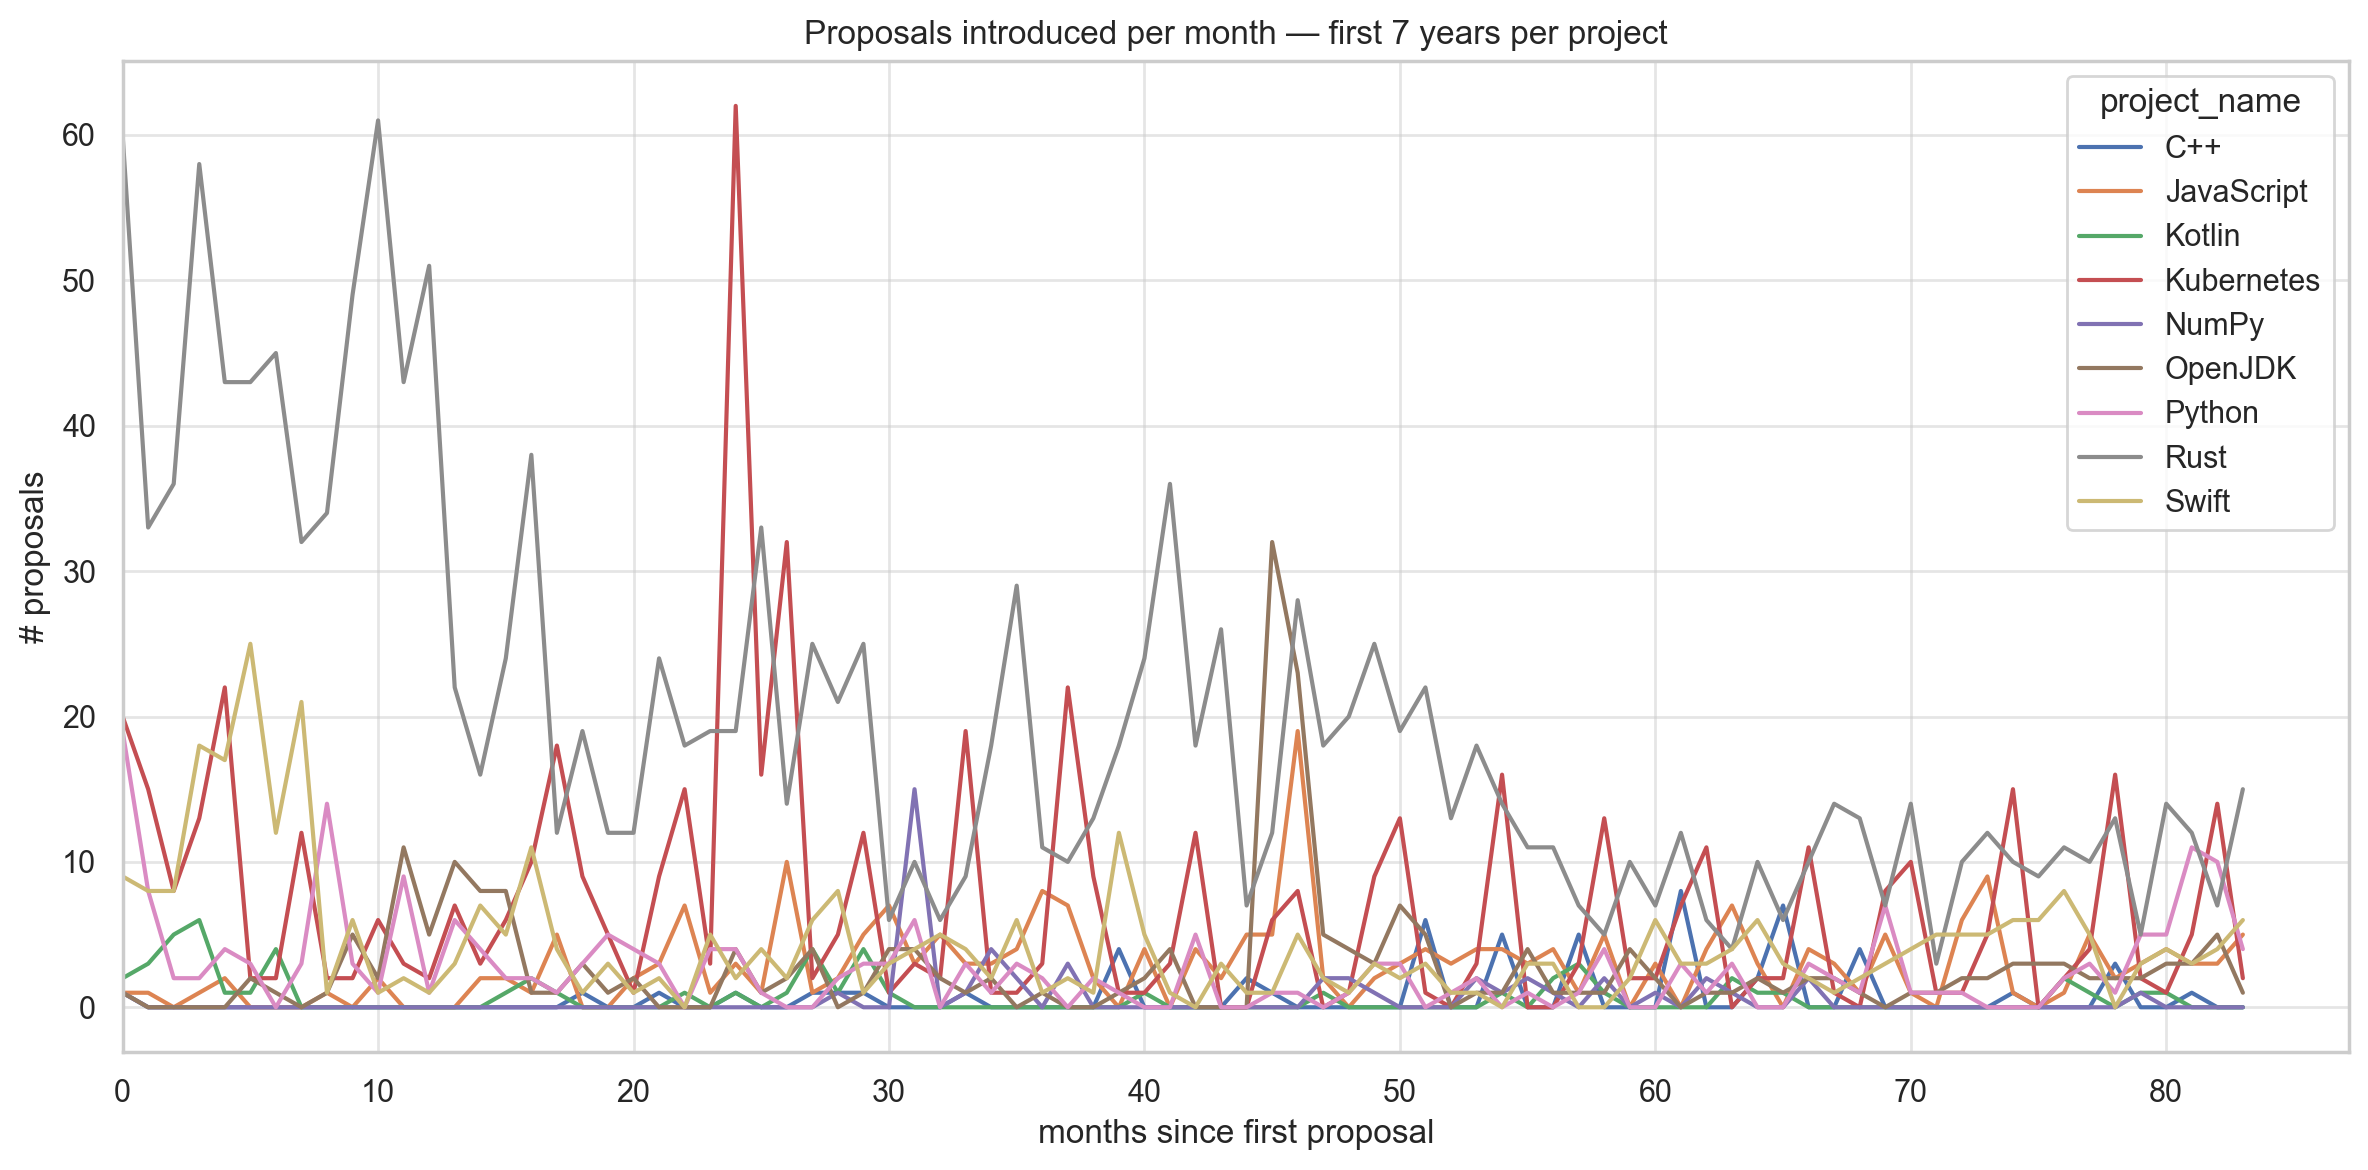

In [38]:
def _first_n_years(df_long, value_col, n_months=84, kind="flow"):
    """Re-base each project's monthly series onto 'months since its first proposal'
    (offset 0, 1, 2, ...), keeping only the first n_months and clipping to the
    dataset's latest month so future months are never fabricated.
    kind='flow' fills gaps with 0 (e.g. inflow); kind='level' forward-fills the
    last known value (e.g. a cumulative backlog)."""
    cutoff = df_long["month"].max().to_period("M")
    out = []
    for proj, g in df_long.groupby("project_name"):
        s = g.set_index("month")[value_col].sort_index()
        s.index = s.index.to_period("M")
        start = s.index.min()
        n = min(n_months, (cutoff - start).n + 1)
        idx = pd.period_range(start, periods=n, freq="M")
        s = s.reindex(idx, fill_value=0) if kind == "flow" else s.reindex(idx).ffill()
        out.append(pd.DataFrame({
            "project_name": proj,
            "month_offset": list(range(n)),
            value_col: s.to_numpy(),
        }))
    return pd.concat(out, ignore_index=True)


inflow_7y = _first_n_years(monthly_new, "count", n_months=84, kind="flow")
inflow_7y = inflow_7y[inflow_7y["project_name"] != "Pandas"]

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=inflow_7y, x="month_offset", y="count", hue="project_name", ax=ax)
ax.set_xlim(left=0)
ax.set_title("Proposals introduced per month — first 7 years per project")
ax.set_xlabel("months since first proposal")
ax.set_ylabel("# proposals")
plt.tight_layout()
plt.show()

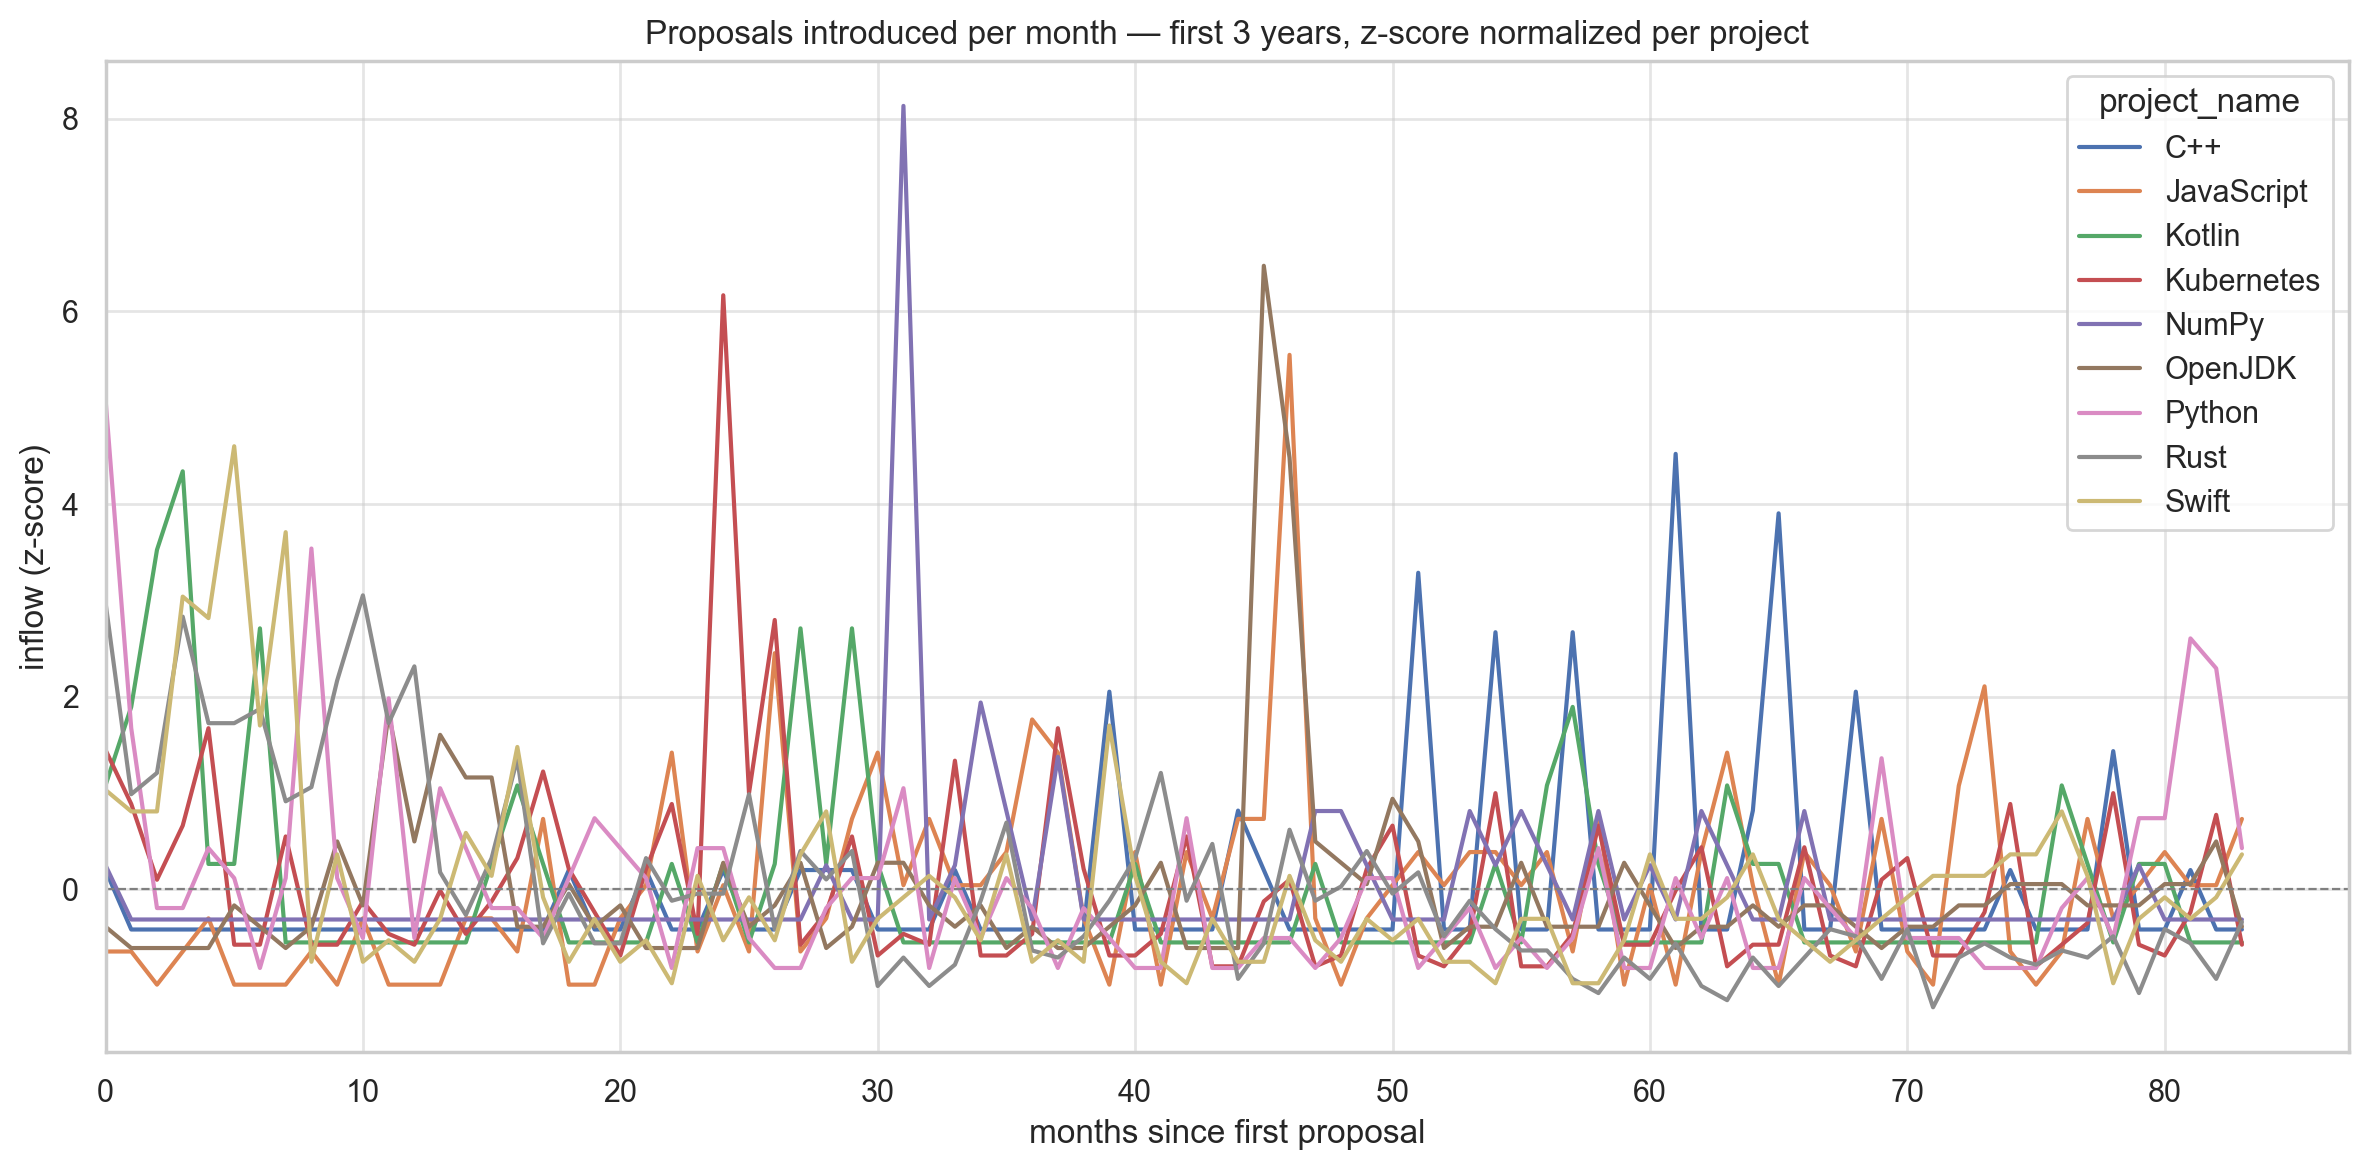

In [39]:
def _zscore_within(df, value_col, by="project_name"):
    """z-score `value_col` within each project, over exactly the rows present
    (here: the first-3-years window), so trajectories are compared on shape."""
    z = lambda s: (s - s.mean()) / s.std(ddof=0) if s.std(ddof=0) > 0 else s * 0.0
    df = df.copy()
    df[f"{value_col}_z"] = df.groupby(by)[value_col].transform(z)
    return df


inflow_7y_z = _zscore_within(inflow_7y, "count")

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=inflow_7y_z, x="month_offset", y="count_z", hue="project_name", ax=ax)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlim(left=0)
ax.set_title("Proposals introduced per month — first 7 years, z-score normalized per project")
ax.set_xlabel("months since first proposal")
ax.set_ylabel("inflow (z-score)")
plt.tight_layout()
plt.show()

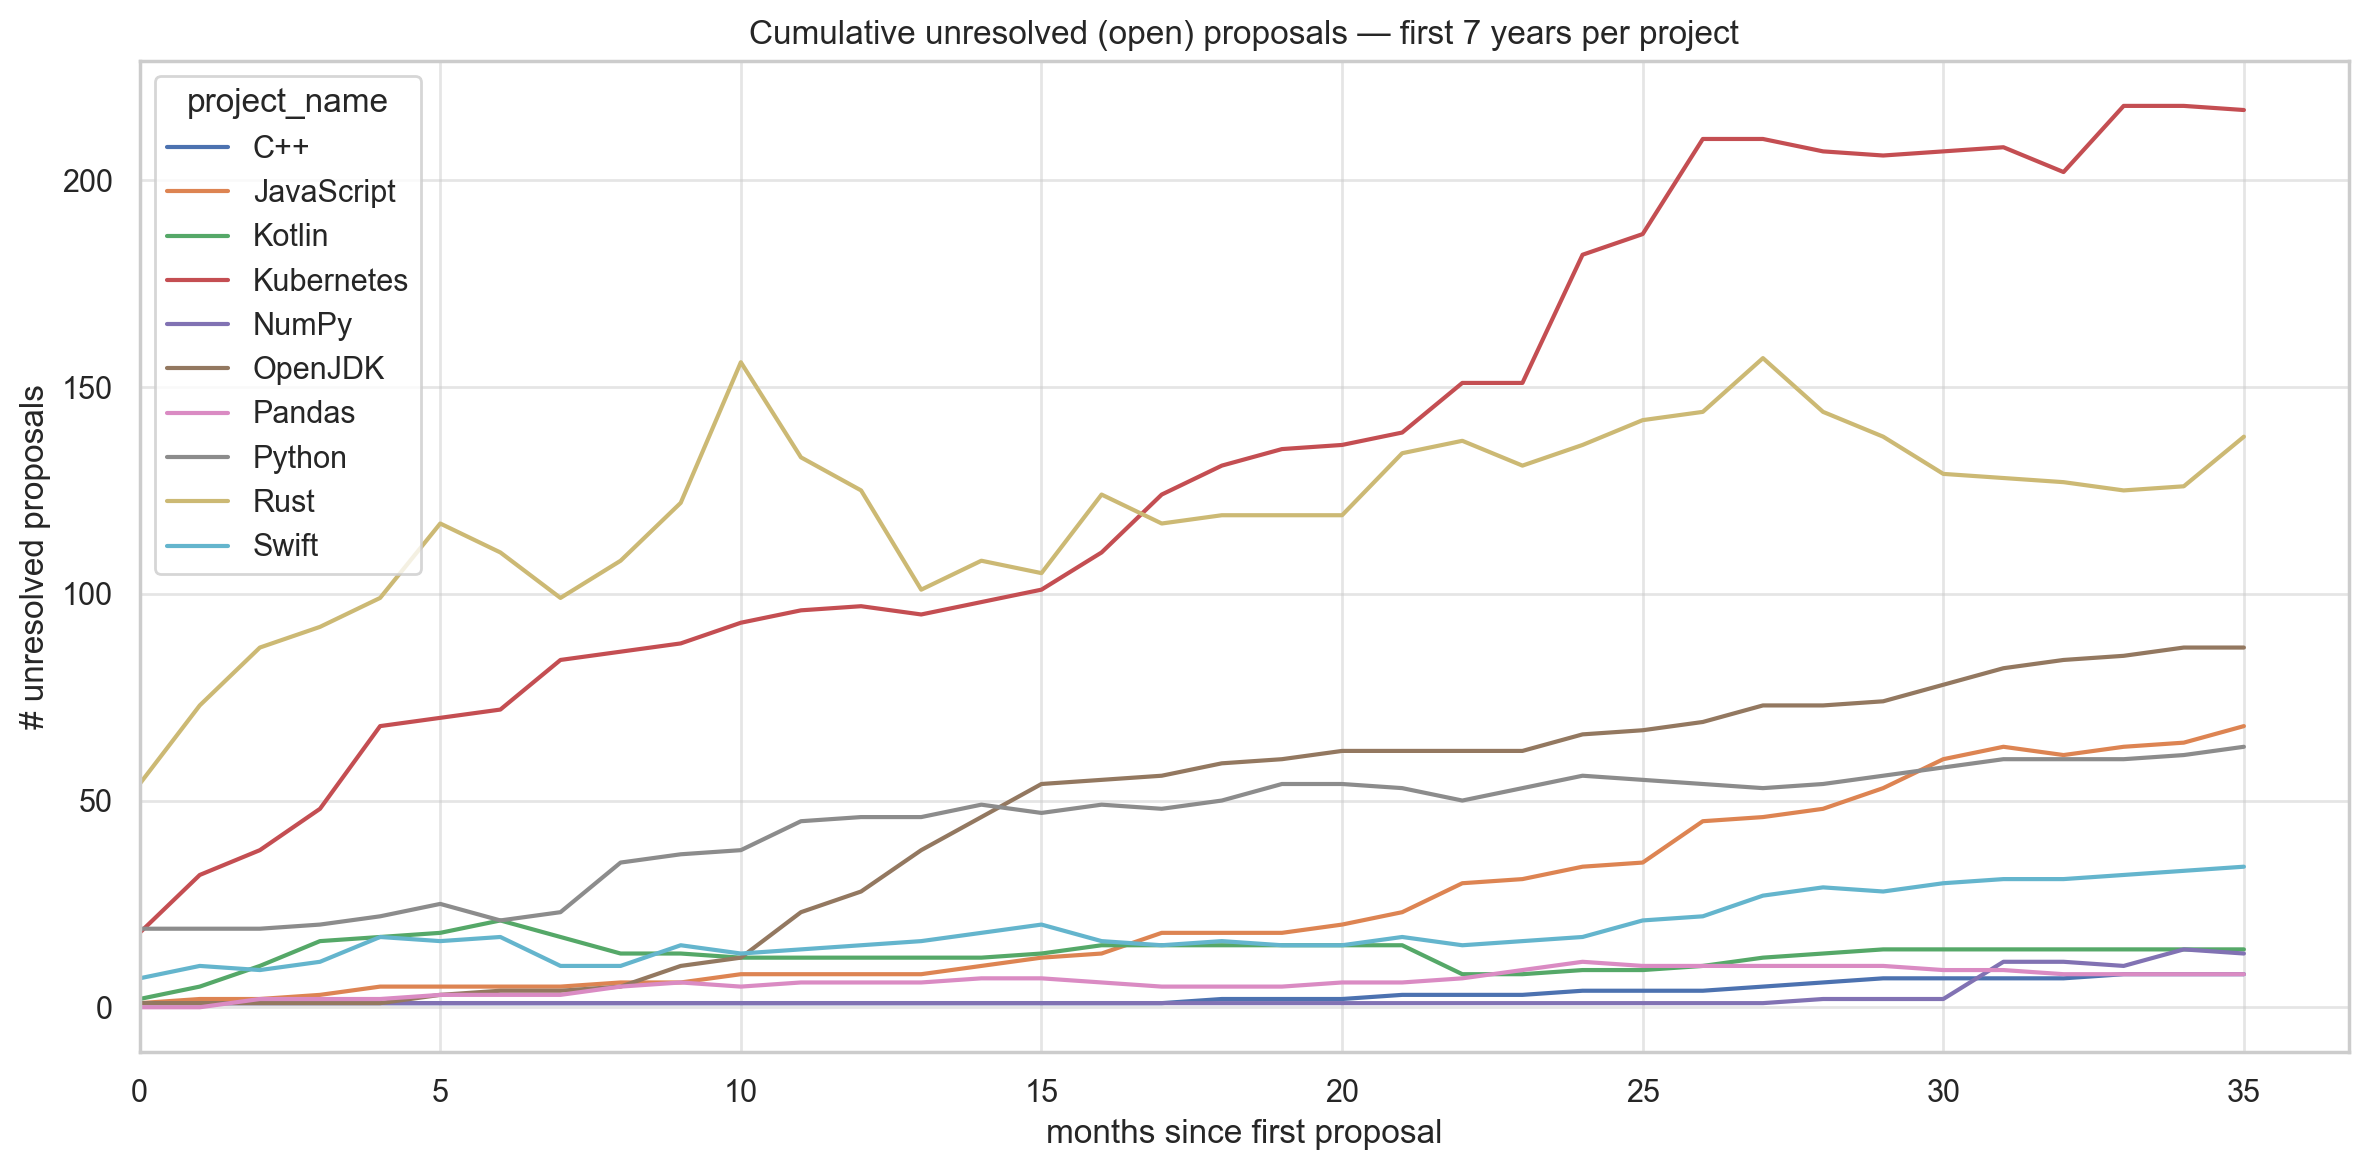

In [40]:
unresolved_7y = _first_n_years(unresolved, "unresolved", n_months=84, kind="level")
unresolved_7y = unresolved_7y[unresolved_7y["project_name"] != "Pandas"]

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=unresolved_3y, x="month_offset", y="unresolved", hue="project_name", ax=ax)
ax.set_xlim(left=0)
ax.set_title("Cumulative unresolved (open) proposals — first 7 years per project")
ax.set_xlabel("months since first proposal")
ax.set_ylabel("# unresolved proposals")
plt.tight_layout()
plt.show()

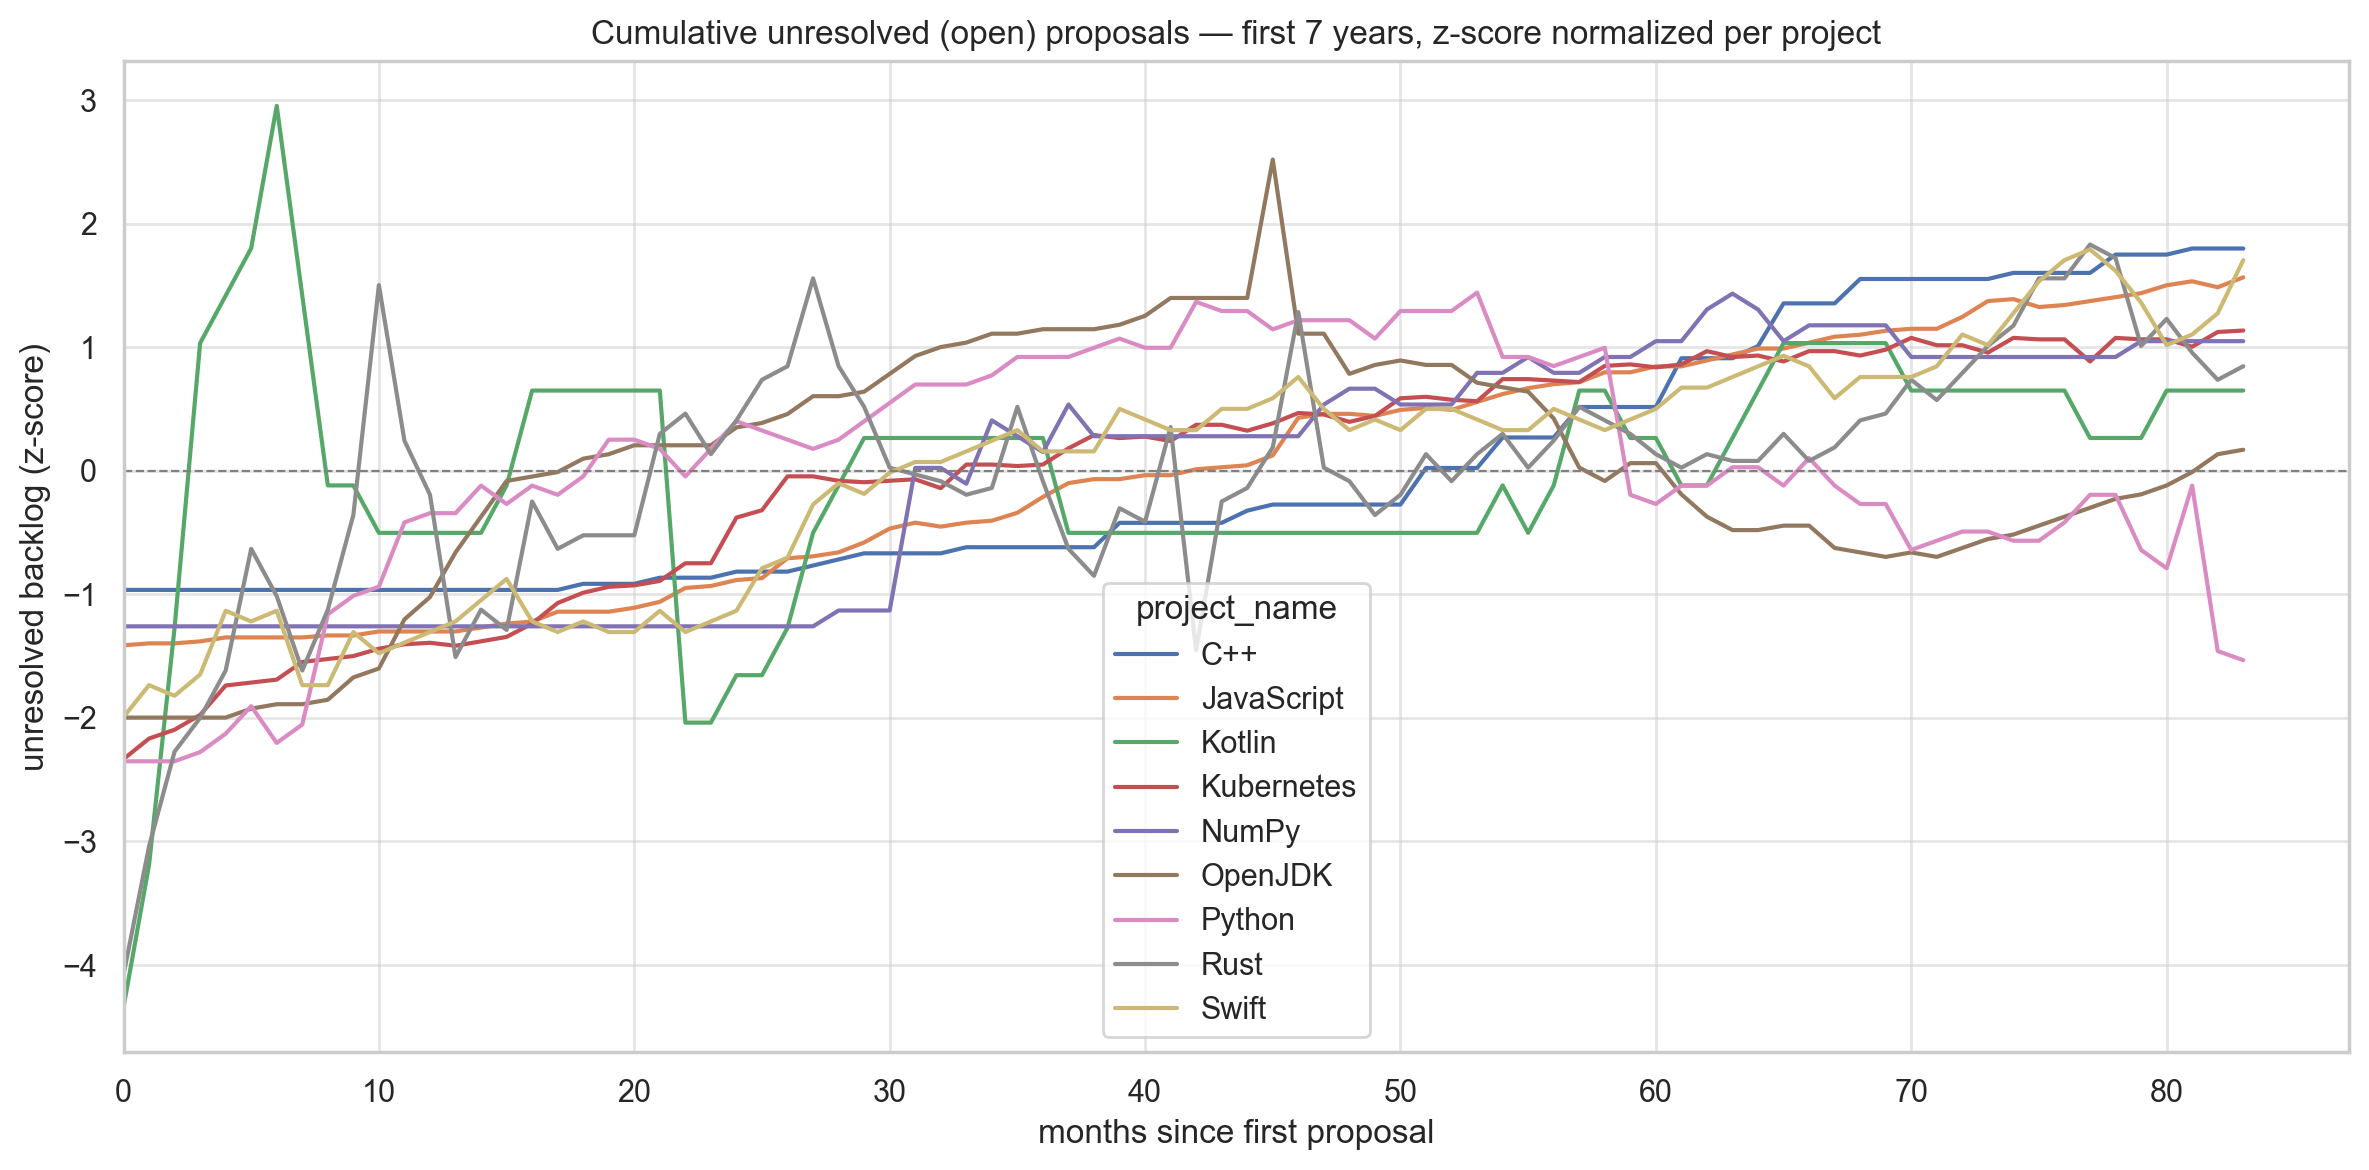

In [41]:
unresolved_7y_z = _zscore_within(unresolved_7y, "unresolved")

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(data=unresolved_7y_z, x="month_offset", y="unresolved_z", hue="project_name", ax=ax)
ax.axhline(0, color="gray", lw=0.8, ls="--")
ax.set_xlim(left=0)
ax.set_title("Cumulative unresolved (open) proposals — first 7 years, z-score normalized per project")
ax.set_xlabel("months since first proposal")
ax.set_ylabel("unresolved backlog (z-score)")
plt.tight_layout()
plt.show()

In [33]:
conn.close()